Bài tập 1: C1.3. BaiTap1.ipynb

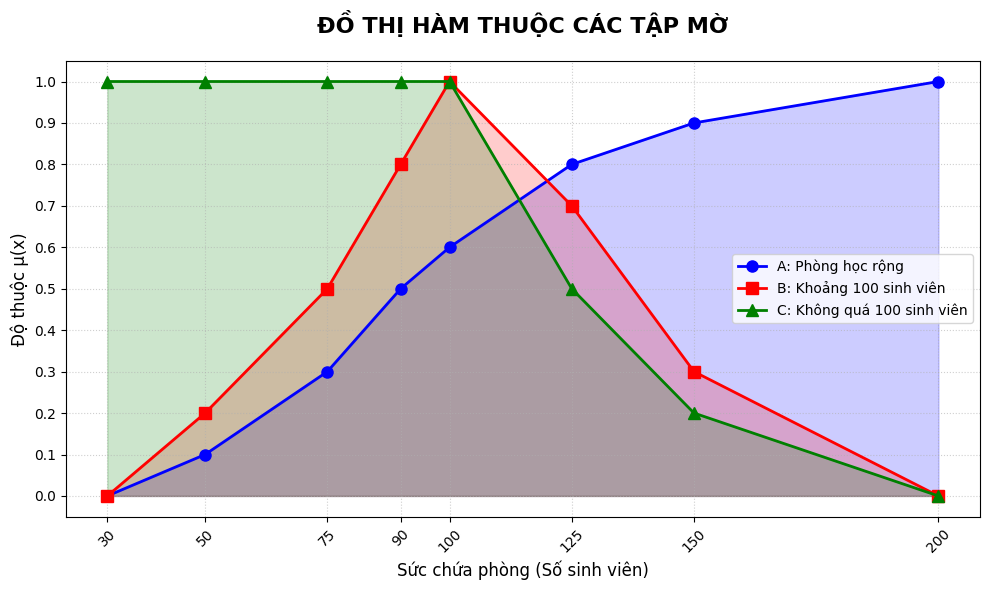

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Định nghĩa tập vũ trụ X và giá trị độ thuộc (gán trực tiếp)
X = np.array([30, 50, 75, 90, 100, 125, 150, 200])

# Tập A: "Phòng học rộng" - độ thuộc tăng dần theo kích thước
mu_A = np.array([0.0, 0.1, 0.3, 0.5, 0.6, 0.8, 0.9, 1.0])

# Tập B: "Phòng chứa khoảng 100 sinh viên" - đỉnh tại 100
mu_B = np.array([0.0, 0.2, 0.5, 0.8, 1.0, 0.7, 0.3, 0.0])

# Tập C: "Phòng không chứa quá 100 sinh viên" - giảm khi > 100
mu_C = np.array([1.0, 1.0, 1.0, 1.0, 1.0, 0.5, 0.2, 0.0])

# 2. Vẽ đồ thị
plt.figure(figsize=(10, 6))

# Vẽ các đường với marker khác nhau để phân biệt
plt.plot(X, mu_A, marker='o', linewidth=2, markersize=8, label='A: Phòng học rộng', color='blue')
plt.plot(X, mu_B, marker='s', linewidth=2, markersize=8, label='B: Khoảng 100 sinh viên', color='red')
plt.plot(X, mu_C, marker='^', linewidth=2, markersize=8, label='C: Không quá 100 sinh viên', color='green')

# Điền vùng dưới đường cong (tùy chọn, giúp đồ thị đẹp hơn)
plt.fill_between(X, mu_A, alpha=0.2, color='blue')
plt.fill_between(X, mu_B, alpha=0.2, color='red')
plt.fill_between(X, mu_C, alpha=0.2, color='green')

# 3. Trang trí đồ thị
plt.title('ĐỒ THỊ HÀM THUỘC CÁC TẬP MỜ', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Sức chứa phòng (Số sinh viên)', fontsize=12)
plt.ylabel('Độ thuộc μ(x)', fontsize=12)
plt.xticks(X, rotation=45)  # Hiển thị đầy đủ các giá trị của X
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10, loc='best')

# 4. Lưu ảnh và hiển thị kết quả
plt.tight_layout()
plt.savefig('baitap1.png', dpi=300, bbox_inches='tight')
plt.show()

Bài 1

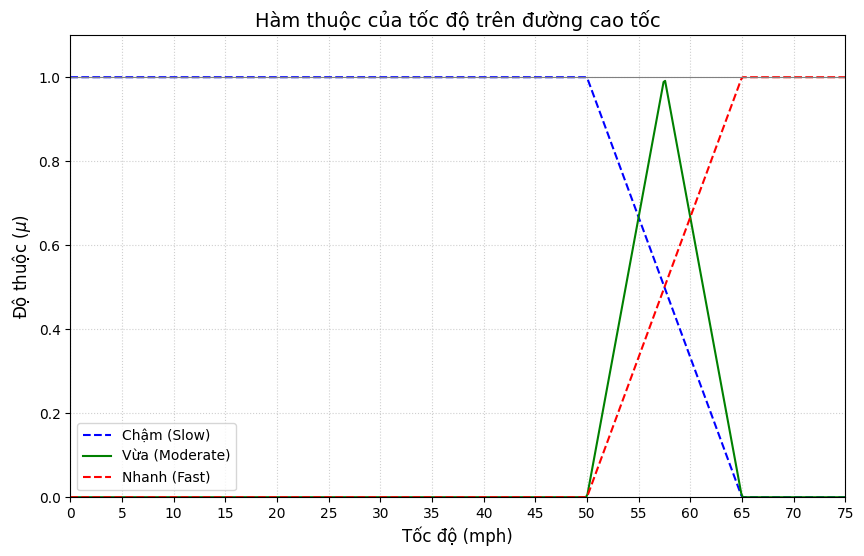

Tốc độ | μ_Chậm  μ_Vừa   μ_Nhanh
--------------------------------------
0      | 1.00    0.00    0.00   
50     | 1.00    0.00    0.00   
57.5   | 0.50    1.00    0.50   
60     | 0.33    0.00    0.67   
65     | 0.00    0.00    1.00   
75     | 0.00    0.00    1.00   
80     | 0.00    0.00    1.00   


In [5]:
import numpy as np
import matplotlib.pyplot as plt

def mu_slow(x):
    """Hàm thuộc cho tập mờ 'Chậm' (Slow)"""
    # Nếu x nằm trong mảng numpy, ta dùng np.where để xử lý vector hóa
    val = np.where(x <= 50, 1.0, 
          np.where(x <= 65, (65 - x) / 15.0, 0.0))
    return val

def mu_fast(x):
    """Hàm thuộc cho tập mờ 'Nhanh' (Fast)"""
    val = np.where(x <= 50, 0.0,
          np.where(x <= 65, (x - 50) / 15.0, 1.0))
    return val

def mu_moderate(x):
    """Hàm thuộc cho tập mờ 'Vừa' (Moderate)
    Giả định dạng tam giác: Đỉnh tại giao điểm (57.5), chân tại 50 và 65"""
    # Tính toán thủ công từng phần cho dễ hiểu
    res = np.zeros_like(x)
    
    # Đoạn lên (50 đến 57.5)
    mask_up = (x > 50) & (x <= 57.5)
    res[mask_up] = (x[mask_up] - 50) / 7.5
    
    # Đoạn xuống (57.5 đến 65)
    mask_down = (x > 57.5) & (x <= 65)
    res[mask_down] = (65 - x[mask_down]) / 7.5
    
    return res

# 1. Tạo dữ liệu tốc độ từ 0 đến 75
speeds = np.linspace(0, 75, 500)

# 2. Tính giá trị hàm thuộc
slow_vals = mu_slow(speeds)
fast_vals = mu_fast(speeds)
moderate_vals = mu_moderate(speeds)

# 3. Vẽ đồ thị
plt.figure(figsize=(10, 6))

plt.plot(speeds, slow_vals, label='Chậm (Slow)', color='blue', linestyle='--')
plt.plot(speeds, moderate_vals, label='Vừa (Moderate)', color='green', linestyle='-') # Thêm phần vừa
plt.plot(speeds, fast_vals, label='Nhanh (Fast)', color='red', linestyle='--')

# 4. Định dạng đồ thị
plt.title('Hàm thuộc của tốc độ trên đường cao tốc', fontsize=14)
plt.xlabel('Tốc độ (mph)', fontsize=12)
plt.ylabel(r'Độ thuộc ($\mu$)', fontsize=12)
plt.xlim(0, 75)
plt.ylim(0, 1.1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(np.arange(0, 80, 5))
plt.legend()
plt.axhline(y=1.0, color='gray', linewidth=0.8)

plt.show()

# 5. In thêm ví dụ cụ thể
example_speeds = [0, 50, 57.5, 60, 65, 75, 80]
print(f"{'Tốc độ':<6} | {'μ_Chậm':<7} {'μ_Vừa':<7} {'μ_Nhanh':<7}")
print("-" * 38)

for speed in example_speeds:
    slow = mu_slow(np.array([speed]))[0]
    moderate = mu_moderate(np.array([speed]))[0]
    fast = mu_fast(np.array([speed]))[0]
    
    # In dòng dữ liệu
    print(f"{speed:<6} | {slow:<7.2f} {moderate:<7.2f} {fast:<7.2f}")

Bài 2

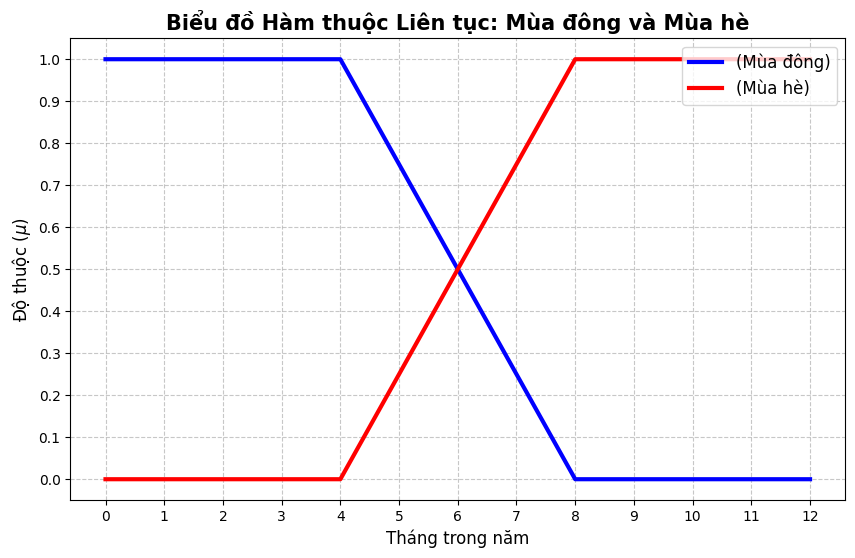

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Định nghĩa hàm thuộc cho Mùa đông (Winter)
def winter_membership(x):
    return np.piecewise(x, [x <= 4, (x > 4) & (x < 8), x >= 8], [1.0, lambda x: 1 - (x - 4)/4, 0.0])

# 2. Định nghĩa hàm thuộc cho Mùa hè (Summer)
def summer_membership(x):
    return np.piecewise(x, [x <= 4, (x > 4) & (x < 8), x >= 8], [0.0, lambda x: (x - 4)/4, 1.0])

# 3. Chuẩn bị dữ liệu
months = np.linspace(0, 12, 1000)
mu_winter = winter_membership(months)
mu_summer = summer_membership(months)

# 4. Vẽ đồ thị (Vẽ cả 2 đường trên cùng 1 figure)
plt.figure(figsize=(10, 6))

# Vẽ đường Mùa đông (màu xanh)
plt.plot(months, mu_winter, label=r'(Mùa đông)', color='blue', linewidth=3)

# Vẽ đường Mùa hè (màu đỏ)
plt.plot(months, mu_summer, label=r'(Mùa hè)', color='red', linewidth=3)

# 5. Trang trí đồ thị
plt.title('Biểu đồ Hàm thuộc Liên tục: Mùa đông và Mùa hè', fontsize=15, fontweight='bold')
plt.xlabel('Tháng trong năm', fontsize=12)
plt.ylabel(r'Độ thuộc ($\mu$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(np.arange(0, 13, 1))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.legend(fontsize=12, loc='upper right')

# Hiển thị
plt.show()

Bài 3

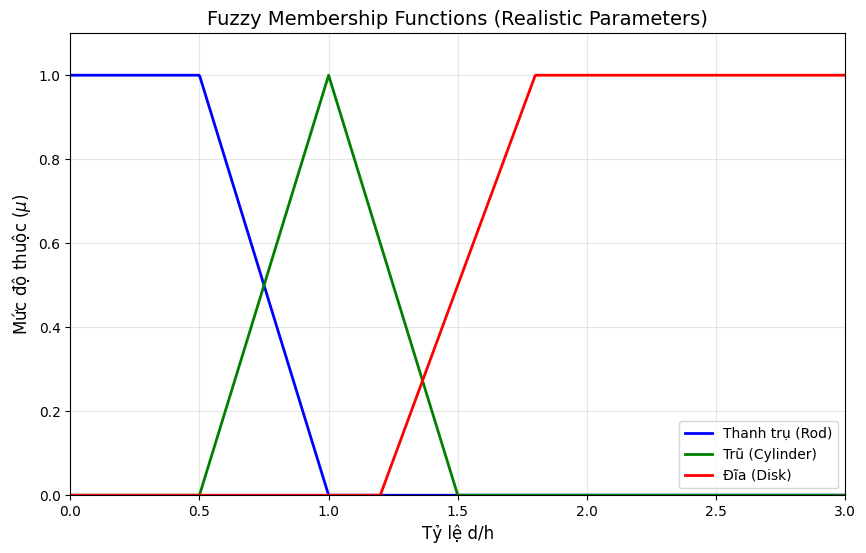

Kiểm tra vùng chuyển tiếp:
d/h = 0.7 -> Rod: 0.33, Cyl: 0.70
d/h = 1.0 -> Rod: 0.00, Cyl: 1.00, Disk: 0.00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def get_realistic_membership_functions():
    x = np.linspace(0, 3, 1000)
    
    mu_rod = np.zeros_like(x)
    mu_cyl = np.zeros_like(x)
    mu_disk = np.zeros_like(x)

    # Thanh trụ (Rod) 
    # Giảm về 0 tại d/h = 1.0
    for i, val in enumerate(x):
        if val <= 0.5:
            mu_rod[i] = 1.0
        elif val <= 1.0:
            # Giảm tuyến tính từ 1 xuống 0 trong khoảng 0.5 -> 1.0
            mu_rod[i] = 1.0 - (val - 0.5) / 0.5 
        else:
            mu_rod[i] = 0.0

    # Đĩa (Disk) 
    # Bắt đầu tăng từ d/h = 1.2 
    # Vì khi d/h < 1.2, vật thể vẫn còn khá cao, chưa dẹt hẳn.
    for i, val in enumerate(x):
        if val <= 1.2:
            mu_disk[i] = 0.0
        elif val <= 1.8:
            mu_disk[i] = (val - 1.2) / 0.6
        else:
            mu_disk[i] = 1.0

    # Trụ (Cylinder)
    # Đỉnh tại 1.0.
    # Chồng lấn với Rod ở khoảng [0.5, 0.8]
    # Chồng lấn với Disk ở khoảng [1.2, 1.5]
    for i, val in enumerate(x):
        if 0.5 <= val <= 1.0:
            # Phần tăng: từ 0.5 đến 1.0
            mu_cyl[i] = (val - 0.5) / 0.5  # = 2 * (val - 0.5)
        elif 1.0 < val <= 1.5:
            # Phần giảm: từ 1.0 đến 1.5
            mu_cyl[i] = (1.5 - val) / 0.5  # = 2 * (1.5 - val)
        else:
            mu_cyl[i] = 0.0

    return x, mu_rod, mu_cyl, mu_disk

# Vẽ đồ thị mới
x, mu_rod, mu_cyl, mu_disk = get_realistic_membership_functions()

plt.figure(figsize=(10, 6))
plt.plot(x, mu_rod, label='Thanh trụ (Rod)', linewidth=2, color='blue')
plt.plot(x, mu_cyl, label='Trũ (Cylinder)', linewidth=2, color='green')
plt.plot(x, mu_disk, label='Đĩa (Disk)', linewidth=2, color='red')

plt.title('Fuzzy Membership Functions (Realistic Parameters)', fontsize=14)
plt.xlabel('Tỷ lệ d/h', fontsize=12)
plt.ylabel(r'Mức độ thuộc ($\mu$)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 3)
plt.ylim(0, 1.1)
plt.show()